In [1]:

#Building an End-to-End Geospatial Data Pipeline with Python. 
#Install  necessary Libraries
%pip install pandas geopandas matplotlib shapely
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import json
import shapely
from shapely.geometry import shape
from shapely.geometry.base import BaseGeometry

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
# Check your current directory
print(os.getcwd())
# Change the directory to your workspace folder
os.chdir(r"C:\Users\visha\geospatial_pipeline")

C:\Users\visha\geospatial_pipeline\Scripts


In [3]:
#Define the file paths:
BASE_DIR = Path.cwd()
RAW_DATA = BASE_DIR / "Data" / "Raw"
PROCESSED_DATA = BASE_DIR / "Data" / "Processed"
OUTPUTS = BASE_DIR / "Outputs"
MAPS = OUTPUTS / "Maps"
TABLES = OUTPUTS / "Tables"
for folder in [PROCESSED_DATA, MAPS, TABLES]:
    folder.mkdir(parents=True, exist_ok=True)

In [4]:
#Step 3: Load the Raw Data

#Load the service-location table and neighbourhood boundary file.

services = pd.read_csv(RAW_DATA / "Tennis Courts Facilities - 4326.csv")
neighbourhoods = gpd.read_file(RAW_DATA / "Neighbourhoods - 4326.geojson")

print(services.head())
print(neighbourhoods.head())

   _id    ID                 Name    Type Lights  Courts         Phone  \
0    1  2341       Agincourt Park    Club    Yes       4           311   
1    2  1044         Alamosa Park    Club     No       3  416-496-0225   
2    3   923  Albion Gardens Park  Public    Yes       3           311   
3    4   484        Amesbury Park  Public     No       2           311   
4    5   491        Ancaster Park  Public     No       3           311   

                  ClubName                        ClubWebsite ClubInfo  \
0    Agincourt Tennis Club  http://www.agincourttennisclub.ca      NaN   
1  Bridlebrook Tennis Club                http://www.nyta.org      NaN   
2                      NaN                                NaN      NaN   
3                      NaN                                NaN      NaN   
4                      NaN                                NaN      NaN   

        LocationAddress WinterPlay  \
0  27  Glen Watford Dr         NaN   
1      111  Alamosa Dr         NaN

In [5]:
#Check the type of the Geometry column
print(type(services["geometry"].iloc[0]))
print(services["geometry"].iloc[0])

<class 'str'>
{"coordinates": [[-79.2749181798, 43.7882598434]], "type": "MultiPoint"}


In [6]:
#This converts  text like JSON into a Shapely MultiPoint geometry.
services["geometry"] = services["geometry"].apply(
    lambda x: shape(json.loads(x))
    if not isinstance(x, BaseGeometry)
    else x
)

In [8]:
#Create the GeoDataFrame
services_gdf = gpd.GeoDataFrame(
    services,
    geometry="geometry",
    crs="EPSG:4326"
)
print(type(services_gdf))
print(services_gdf.head())
print(services_gdf.crs)

<class 'geopandas.geodataframe.GeoDataFrame'>
   _id    ID                 Name    Type Lights  Courts         Phone  \
0    1  2341       Agincourt Park    Club    Yes       4           311   
1    2  1044         Alamosa Park    Club     No       3  416-496-0225   
2    3   923  Albion Gardens Park  Public    Yes       3           311   
3    4   484        Amesbury Park  Public     No       2           311   
4    5   491        Ancaster Park  Public     No       3           311   

                  ClubName                        ClubWebsite ClubInfo  \
0    Agincourt Tennis Club  http://www.agincourttennisclub.ca      NaN   
1  Bridlebrook Tennis Club                http://www.nyta.org      NaN   
2                      NaN                                NaN      NaN   
3                      NaN                                NaN      NaN   
4                      NaN                                NaN      NaN   

        LocationAddress WinterPlay                           geo

In [9]:
#inspect the data
print(services_gdf.info())
print(services_gdf.isna().sum())

print(neighbourhoods.info())
print(neighbourhoods.crs)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 172 entries, 0 to 171
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   _id              172 non-null    int64   
 1   ID               172 non-null    int64   
 2   Name             172 non-null    str     
 3   Type             171 non-null    str     
 4   Lights           172 non-null    str     
 5   Courts           172 non-null    int64   
 6   Phone            172 non-null    str     
 7   ClubName         63 non-null     str     
 8   ClubWebsite      56 non-null     str     
 9   ClubInfo         1 non-null      str     
 10  LocationAddress  172 non-null    str     
 11  WinterPlay       63 non-null     str     
 12  geometry         172 non-null    geometry
dtypes: geometry(1), int64(3), str(9)
memory usage: 29.0 KB
None
_id                  0
ID                   0
Name                 0
Type                 1
Lights               0
Co

In [16]:

#Step 4: Clean and Standardize the Tabular Data
#Standardize column names
services_gdf.columns = (
    services.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

neighbourhoods.columns = (
    neighbourhoods.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(services_gdf.columns)
print(neighbourhoods.columns)

Index(['_id', 'id', 'name', 'type', 'lights', 'courts', 'phone', 'clubname',
       'clubwebsite', 'clubinfo', 'locationaddress', 'winterplay', 'geometry'],
      dtype='str')
Index(['_id', 'area_id', 'area_attr_id', 'parent_area_id', 'area_short_code',
       'area_long_code', 'area_name', 'area_desc', 'classification',
       'classification_code', 'objectid', 'geometry'],
      dtype='str')


In [17]:
#remove duplicates
services_gdf = services_gdf.drop_duplicates(subset="id")

In [18]:
#remove unwanted columns

services_gdf = services_gdf.drop(columns=["clubname", "clubwebsite", "clubinfo"])

In [13]:
#validate geometry
print(services_gdf.geometry.is_valid.all())
print(services_gdf.geometry.is_empty.sum())
print(services_gdf.crs)

True
0
EPSG:4326


In [21]:
neighbourhoods_clean = neighbourhoods[
    neighbourhoods.geometry.notna() &
    neighbourhoods.geometry.is_valid &
    (~neighbourhoods.geometry.is_empty)
].copy()

In [ ]:
# Missing geometries
missing_geom = neighbourhoods.geometry.isna().sum()

# Invalid geometries
invalid_geom = (~neighbourhoods.geometry.is_valid).sum()

# Empty geometries
empty_geom = neighbourhoods.geometry.is_empty.sum()

print("Missing geometries:", missing_geom)
print("Invalid geometries:", invalid_geom)
print("Empty geometries:", empty_geom)
#check crs
print(neighbourhoods_clean.crs)

In [22]:
print(neighbourhoods_clean.crs)

EPSG:4326


In [23]:
#check for duplicate IDs
print("Duplicate AREA_IDs:",
      neighbourhoods_clean["area_id"].duplicated().sum())

Duplicate AREA_IDs: 0


In [24]:
#create a QA summary
qa_summary = pd.DataFrame({
    "metric": [
        "Raw neighbourhoods",
        "Missing geometries",
        "Invalid geometries",
        "Empty geometries",
        "Neighbourhoods retained"
    ],
    "count": [
        len(neighbourhoods),
        missing_geom,
        invalid_geom,
        empty_geom,
        len(neighbourhoods_clean)
    ]
})

print(qa_summary)

qa_summary.to_csv(TABLES / "neighbourhood_quality_summary.csv",
                  index=False)


                    metric  count
0       Raw neighbourhoods    158
1       Missing geometries      0
2       Invalid geometries      0
3         Empty geometries      0
4  Neighbourhoods retained    158


In [26]:
#Step : Perform a Spatial Join
#A spatial join assigns each service location to the neighbourhood polygon that contains it.
services_with_neighbourhood = gpd.sjoin(
    services_gdf,
    neighbourhoods[["area_name", "geometry"]],
    how="left",
    predicate="within"
)
#Review records that did not match a neighbourhood
unmatched_records = services_with_neighbourhood[
    services_with_neighbourhood["area_name"].isna()
]

print(f"Unmatched records: {len(unmatched_records)}")

#Export unmatched records for review
unmatched_records.to_csv(
    TABLES / "unmatched_service_locations.csv",
    index=False
)


Unmatched records: 1


In [31]:
#calculate the number of service locations in each neighbourhood.
service_counts = (
    services_with_neighbourhood
    .groupby("area_name")
    .size()
    .reset_index(name="service_count")
)
#Join the counts back to the neighbourhood boundaries:
neighbourhood_summary = neighbourhoods.merge(
    service_counts,
    on="area_name",
    how="left"
)

neighbourhood_summary["service_count"] = (
    neighbourhood_summary["service_count"]
    .fillna(0)
    .astype(int)
)

#You can also create counts by service type:
service_type_counts = pd.crosstab(
    services_with_neighbourhood["area_name"],
    services_with_neighbourhood["type"]
).reset_index()

print(service_type_counts.head())


type                     area_name  Club  Public
0                  Agincourt North     1       0
1     Agincourt South-Malvern West     1       1
2                        Alderwood     0       1
3                            Annex     0       1
4                         Avondale     0       1


In [32]:
# Export Analysis-Ready Outputs
#Export the processed point data, neighbourhood summary, and non-spatial table.
services_with_neighbourhood.to_file(
    PROCESSED_DATA / "service_locations_with_neighbourhood.geojson",
    driver="GeoJSON"
)

neighbourhood_summary.to_file(
    PROCESSED_DATA / "neighbourhood_service_summary.geojson",
    driver="GeoJSON"
)

neighbourhood_summary.drop(columns="geometry").to_csv(
    TABLES / "neighbourhood_service_summary.csv",
    index=False
)


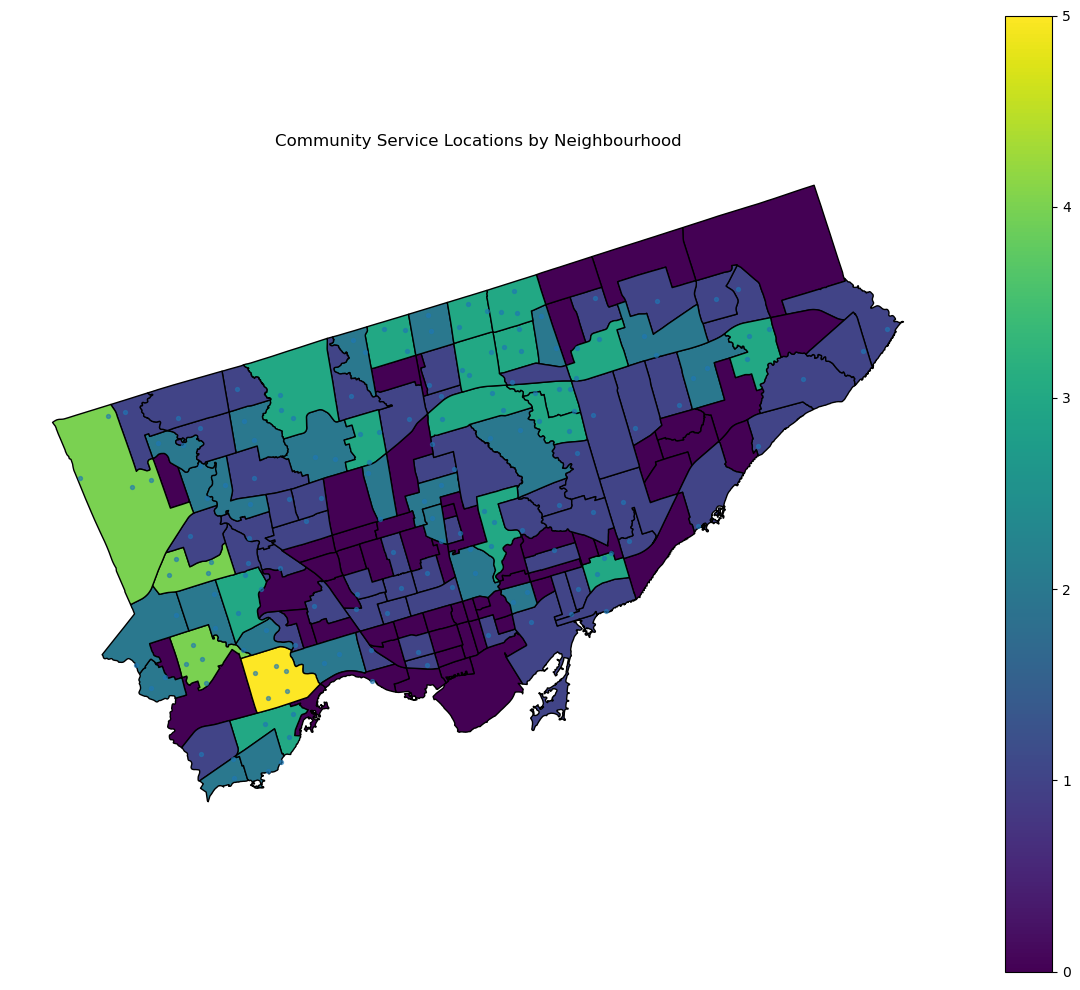

In [33]:
#Step 11: Create a Quality-Assurance Map
fig, ax = plt.subplots(figsize=(12, 10))

neighbourhood_summary.plot(
    column="service_count",
    legend=True,
    ax=ax,
    edgecolor="black"
)

services_gdf.plot(
    ax=ax,
    markersize=8,
    alpha=0.6
)

ax.set_title("Community Service Locations by Neighbourhood")
ax.set_axis_off()

plt.tight_layout()
plt.savefig(MAPS / "service_locations_by_neighbourhood.png", dpi=300)
plt.show()


In [34]:
# Make the Pipeline Reusable

def load_data():
    pass

def clean_data(data):
    pass

def validate_data(data):
    pass

def create_geodataframe(data):
    pass

def spatial_join(points, boundaries):
    pass

def create_summary(joined_data, boundaries):
    pass

def export_outputs(points, summary):
    pass
#This approach makes the workflow easier to test, troubleshoot, document, and maintain.
